In [1]:
!pip -q install nltk

import copy
import io
import json
import math
import os
import random
import re
import shutil
import time
import unicodedata
import warnings

from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from nltk.translate.bleu_score import (
    SmoothingFunction,
    corpus_bleu,
    sentence_bleu
)

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
SEED = 42
SPLIT_SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("A GPU is recommended for the eight experiments.")

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import files

uploaded = files.upload()
DATA_FILE = list(uploaded.keys())[0]

print("Dataset file:", DATA_FILE)

Saving vast_english_french.txt to vast_english_french (2).txt
Dataset file: vast_english_french (2).txt


In [4]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.strip()
    text = re.sub(r"\s+", " ", text)

    return text


def load_translation_pairs(file_path):
    pairs = []

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as file:

        for line in file:
            line = line.strip()

            if not line:
                continue

            if "\t" in line:
                parts = line.split("\t")

            elif "|||" in line:
                parts = line.split("|||")

            else:
                continue

            if len(parts) < 2:
                continue

            english_sentence = normalize_text(parts[0])
            french_sentence = normalize_text(parts[1])

            if english_sentence and french_sentence:
                pairs.append(
                    (english_sentence, french_sentence)
                )

    return pairs


all_pairs = load_translation_pairs(DATA_FILE)

if len(all_pairs) == 0:
    raise ValueError(
        "No English-French sentence pairs were detected. "
        "Check the dataset separator."
    )

print("Total sentence pairs:", len(all_pairs))
print()

for english_sentence, french_sentence in all_pairs[:5]:
    print("English:", english_sentence)
    print("French: ", french_sentence)
    print()

Total sentence pairs: 555

English: I am cold
French:  J'ai froid

English: You are tired
French:  Tu es fatigué

English: He is hungry
French:  Il a faim

English: She is happy
French:  Elle est heureuse

English: We are friends
French:  Nous sommes amis



In [5]:
QUICK_TEST = False

if QUICK_TEST:
    all_pairs = all_pairs[:500]
    NUMBER_OF_EPOCHS = 30
    EARLY_STOPPING_PATIENCE = 6

    print("QUICK TEST MODE")
    print("Pairs used:", len(all_pairs))

else:
    NUMBER_OF_EPOCHS = 10
    EARLY_STOPPING_PATIENCE = 3

    print("FINAL MODE")
    print("Pairs used:", len(all_pairs))

FINAL MODE
Pairs used: 555


In [6]:
TRAIN_INDEX_FILE = "/content/homework4_train_indices.npy"
VALIDATION_INDEX_FILE = "/content/homework4_validation_indices.npy"

if (
    os.path.exists(TRAIN_INDEX_FILE)
    and os.path.exists(VALIDATION_INDEX_FILE)
    and not QUICK_TEST
):
    train_indices = np.load(TRAIN_INDEX_FILE)
    validation_indices = np.load(
        VALIDATION_INDEX_FILE
    )

    print("Loaded saved Problem 3 split indices.")

else:
    all_indices = np.arange(len(all_pairs))

    train_indices, validation_indices = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=SPLIT_SEED,
        shuffle=True
    )

    np.save(
        "problem4_train_indices.npy",
        train_indices
    )

    np.save(
        "problem4_validation_indices.npy",
        validation_indices
    )

    print("Created reproducible 80/20 split.")


train_pairs = [
    all_pairs[index]
    for index in train_indices
]

validation_pairs = [
    all_pairs[index]
    for index in validation_indices
]

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(validation_pairs))

print(
    "Training percentage:",
    round(100 * len(train_pairs) / len(all_pairs), 2)
)

print(
    "Validation percentage:",
    round(100 * len(validation_pairs) / len(all_pairs), 2)
)

Created reproducible 80/20 split.
Training pairs: 444
Validation pairs: 111
Training percentage: 80.0
Validation percentage: 20.0


In [7]:
LOWERCASE = True

TOKEN_PATTERN = re.compile(
    r"[^\W_]+(?:['’-][^\W_]+)*|[^\w\s]",
    flags=re.UNICODE
)


def tokenize(sentence):
    sentence = normalize_text(sentence)

    if LOWERCASE:
        sentence = sentence.lower()

    return TOKEN_PATTERN.findall(sentence)


def detokenize(tokens):
    text = " ".join(tokens)

    text = re.sub(
        r"\s+([.,!?;:%\)\]\}])",
        r"\1",
        text
    )

    text = re.sub(
        r"([\(\[\{])\s+",
        r"\1",
        text
    )

    text = text.replace(" ' ", "'")
    text = text.replace(" ’ ", "’")

    return text


print("French tokens:")
print(tokenize(train_pairs[0][1]))

print("\nEnglish tokens:")
print(tokenize(train_pairs[0][0]))

French tokens:
['ils', 'pratiquent', 'le', 'piano', 'tous', 'les', 'après-midi']

English tokens:
['they', 'practice', 'piano', 'every', 'afternoon']


In [8]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

SPECIAL_TOKENS = [
    PAD_TOKEN,
    UNK_TOKEN,
    BOS_TOKEN,
    EOS_TOKEN
]

MIN_FREQUENCY = 1
MAX_ENGLISH_VOCABULARY = 50000
MAX_FRENCH_VOCABULARY = 50000


def build_vocabulary(
    sentences,
    minimum_frequency=2,
    maximum_size=20000
):
    token_counter = Counter()

    for sentence in sentences:
        token_counter.update(
            tokenize(sentence)
        )

    vocabulary_tokens = [
        token
        for token, frequency in token_counter.most_common()
        if frequency >= minimum_frequency
    ]

    available_positions = (
        maximum_size - len(SPECIAL_TOKENS)
    )

    vocabulary_tokens = vocabulary_tokens[
        :available_positions
    ]

    index_to_token = (
        SPECIAL_TOKENS + vocabulary_tokens
    )

    token_to_index = {
        token: index
        for index, token in enumerate(index_to_token)
    }

    return token_to_index, index_to_token


training_english_sentences = [
    english
    for english, french in train_pairs
]

training_french_sentences = [
    french
    for english, french in train_pairs
]

english_token_to_index, english_index_to_token = (
    build_vocabulary(
        training_english_sentences,
        minimum_frequency=MIN_FREQUENCY,
        maximum_size=MAX_ENGLISH_VOCABULARY
    )
)

french_token_to_index, french_index_to_token = (
    build_vocabulary(
        training_french_sentences,
        minimum_frequency=MIN_FREQUENCY,
        maximum_size=MAX_FRENCH_VOCABULARY
    )
)

ENGLISH_VOCABULARY_SIZE = len(
    english_index_to_token
)

FRENCH_VOCABULARY_SIZE = len(
    french_index_to_token
)

ENGLISH_PAD_INDEX = english_token_to_index[PAD_TOKEN]
ENGLISH_UNK_INDEX = english_token_to_index[UNK_TOKEN]
ENGLISH_BOS_INDEX = english_token_to_index[BOS_TOKEN]
ENGLISH_EOS_INDEX = english_token_to_index[EOS_TOKEN]

FRENCH_PAD_INDEX = french_token_to_index[PAD_TOKEN]
FRENCH_UNK_INDEX = french_token_to_index[UNK_TOKEN]
FRENCH_BOS_INDEX = french_token_to_index[BOS_TOKEN]
FRENCH_EOS_INDEX = french_token_to_index[EOS_TOKEN]

print(
    "English vocabulary size:",
    ENGLISH_VOCABULARY_SIZE
)

print(
    "French vocabulary size:",
    FRENCH_VOCABULARY_SIZE
)

English vocabulary size: 894
French vocabulary size: 994


In [9]:
english_lengths = [
    len(tokenize(english_sentence)) + 2
    for english_sentence, french_sentence in train_pairs
]

french_lengths = [
    len(tokenize(french_sentence)) + 2
    for english_sentence, french_sentence in train_pairs
]

MAX_ENGLISH_LENGTH = int(
    np.percentile(english_lengths, 95)
)

MAX_FRENCH_LENGTH = int(
    np.percentile(french_lengths, 95)
)

MAX_ENGLISH_LENGTH = min(
    max(MAX_ENGLISH_LENGTH, 10),
    40
)

MAX_FRENCH_LENGTH = min(
    max(MAX_FRENCH_LENGTH, 10),
    45
)

print("Maximum French source length:", MAX_FRENCH_LENGTH)
print("Maximum English target length:", MAX_ENGLISH_LENGTH)

Maximum French source length: 12
Maximum English target length: 11


In [10]:
def encode_sentence(
    sentence,
    token_to_index,
    maximum_length
):
    unknown_index = token_to_index[UNK_TOKEN]
    beginning_index = token_to_index[BOS_TOKEN]
    ending_index = token_to_index[EOS_TOKEN]
    padding_index = token_to_index[PAD_TOKEN]

    sentence_tokens = tokenize(sentence)

    token_indices = [
        token_to_index.get(
            token,
            unknown_index
        )
        for token in sentence_tokens
    ]

    token_indices = token_indices[
        :maximum_length - 2
    ]

    encoded_sentence = (
        [beginning_index]
        + token_indices
        + [ending_index]
    )

    padding_needed = (
        maximum_length - len(encoded_sentence)
    )

    encoded_sentence += [
        padding_index
    ] * padding_needed

    return encoded_sentence


def encode_french_to_english_pairs(sentence_pairs):
    french_encoded = []
    english_encoded = []

    for english_sentence, french_sentence in sentence_pairs:
        french_encoded.append(
            encode_sentence(
                french_sentence,
                french_token_to_index,
                MAX_FRENCH_LENGTH
            )
        )

        english_encoded.append(
            encode_sentence(
                english_sentence,
                english_token_to_index,
                MAX_ENGLISH_LENGTH
            )
        )

    french_tensor = torch.tensor(
        french_encoded,
        dtype=torch.long
    )

    english_tensor = torch.tensor(
        english_encoded,
        dtype=torch.long
    )

    return french_tensor, english_tensor

In [11]:
train_french_tensor, train_english_tensor = (
    encode_french_to_english_pairs(train_pairs)
)

validation_french_tensor, validation_english_tensor = (
    encode_french_to_english_pairs(validation_pairs)
)

print(
    "Training French source shape:",
    train_french_tensor.shape
)

print(
    "Training English target shape:",
    train_english_tensor.shape
)

print(
    "Validation French source shape:",
    validation_french_tensor.shape
)

print(
    "Validation English target shape:",
    validation_english_tensor.shape
)

Training French source shape: torch.Size([444, 12])
Training English target shape: torch.Size([444, 11])
Validation French source shape: torch.Size([111, 12])
Validation English target shape: torch.Size([111, 11])


In [12]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    train_french_tensor,
    train_english_tensor
)

validation_dataset = TensorDataset(
    validation_french_tensor,
    validation_english_tensor
)

training_generator = torch.Generator()
training_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=training_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches: 7
Validation batches: 2


In [13]:
def clean_token_indices(
    token_indices,
    index_to_token
):
    tokens = []

    for index in token_indices:
        index = int(index)
        token = index_to_token[index]

        if token == EOS_TOKEN:
            break

        if token not in {
            PAD_TOKEN,
            BOS_TOKEN,
            EOS_TOKEN
        }:
            tokens.append(token)

    return tokens


def decode_indices(
    token_indices,
    index_to_token
):
    return detokenize(
        clean_token_indices(
            token_indices,
            index_to_token
        )
    )


example_french, example_english = train_dataset[0]

print(
    "French source:",
    decode_indices(
        example_french,
        french_index_to_token
    )
)

print(
    "English target:",
    decode_indices(
        example_english,
        english_index_to_token
    )
)

French source: ils pratiquent le piano tous les après-midi
English target: they practice piano every afternoon


In [14]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(
        self,
        d_model,
        maximum_length,
        dropout=0.10
    ):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        positional_encoding = torch.zeros(
            maximum_length,
            d_model
        )

        positions = torch.arange(
            maximum_length,
            dtype=torch.float
        ).unsqueeze(1)

        division_terms = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float
            )
            * (
                -math.log(10000.0)
                / d_model
            )
        )

        positional_encoding[:, 0::2] = torch.sin(
            positions * division_terms
        )

        positional_encoding[:, 1::2] = torch.cos(
            positions * division_terms
        )

        positional_encoding = positional_encoding.unsqueeze(0)

        self.register_buffer(
            "positional_encoding",
            positional_encoding
        )

    def forward(self, token_embeddings):
        sequence_length = token_embeddings.size(1)

        token_embeddings = (
            token_embeddings
            + self.positional_encoding[
                :,
                :sequence_length,
                :
            ]
        )

        return self.dropout(token_embeddings)

In [15]:
class TranslationTransformer(nn.Module):
    def __init__(
        self,
        source_vocabulary_size,
        target_vocabulary_size,
        source_padding_index,
        target_padding_index,
        d_model=128,
        number_of_heads=2,
        number_of_layers=2,
        feedforward_size=512,
        dropout=0.10,
        maximum_source_length=45,
        maximum_target_length=40
    ):
        super().__init__()

        if d_model % number_of_heads != 0:
            raise ValueError(
                "d_model must be divisible by number_of_heads."
            )

        self.d_model = d_model
        self.number_of_heads = number_of_heads
        self.number_of_layers = number_of_layers
        self.feedforward_size = feedforward_size

        self.source_padding_index = source_padding_index
        self.target_padding_index = target_padding_index

        self.source_embedding = nn.Embedding(
            source_vocabulary_size,
            d_model,
            padding_idx=source_padding_index
        )

        self.target_embedding = nn.Embedding(
            target_vocabulary_size,
            d_model,
            padding_idx=target_padding_index
        )

        self.source_position = SinusoidalPositionalEncoding(
            d_model=d_model,
            maximum_length=maximum_source_length,
            dropout=dropout
        )

        self.target_position = SinusoidalPositionalEncoding(
            d_model=d_model,
            maximum_length=maximum_target_length,
            dropout=dropout
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=number_of_heads,
            num_encoder_layers=number_of_layers,
            num_decoder_layers=number_of_layers,
            dim_feedforward=feedforward_size,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.output_layer = nn.Linear(
            d_model,
            target_vocabulary_size
        )

    def create_causal_mask(
        self,
        target_length,
        target_device
    ):
        return torch.triu(
            torch.ones(
                target_length,
                target_length,
                dtype=torch.bool,
                device=target_device
            ),
            diagonal=1
        )

    def forward(
        self,
        source_tokens,
        target_input_tokens
    ):
        source_padding_mask = source_tokens.eq(
            self.source_padding_index
        )

        target_padding_mask = target_input_tokens.eq(
            self.target_padding_index
        )

        target_causal_mask = self.create_causal_mask(
            target_input_tokens.size(1),
            target_input_tokens.device
        )

        source_embeddings = (
            self.source_embedding(source_tokens)
            * math.sqrt(self.d_model)
        )

        target_embeddings = (
            self.target_embedding(target_input_tokens)
            * math.sqrt(self.d_model)
        )

        source_embeddings = self.source_position(
            source_embeddings
        )

        target_embeddings = self.target_position(
            target_embeddings
        )

        transformer_output = self.transformer(
            src=source_embeddings,
            tgt=target_embeddings,
            tgt_mask=target_causal_mask,
            src_key_padding_mask=source_padding_mask,
            tgt_key_padding_mask=target_padding_mask,
            memory_key_padding_mask=source_padding_mask
        )

        logits = self.output_layer(
            transformer_output
        )

        return logits

In [16]:
test_model = TranslationTransformer(
    source_vocabulary_size=FRENCH_VOCABULARY_SIZE,
    target_vocabulary_size=ENGLISH_VOCABULARY_SIZE,
    source_padding_index=FRENCH_PAD_INDEX,
    target_padding_index=ENGLISH_PAD_INDEX,
    d_model=128,
    number_of_heads=2,
    number_of_layers=2,
    feedforward_size=512,
    maximum_source_length=MAX_FRENCH_LENGTH,
    maximum_target_length=MAX_ENGLISH_LENGTH
).to(device)

test_source, test_target = next(
    iter(train_loader)
)

test_source = test_source.to(device)
test_target = test_target.to(device)

test_target_input = test_target[:, :-1]

test_logits = test_model(
    test_source,
    test_target_input
)

print("Source shape:", test_source.shape)
print("Target input shape:", test_target_input.shape)
print("Output shape:", test_logits.shape)

expected_shape = (
    test_source.size(0),
    MAX_ENGLISH_LENGTH - 1,
    ENGLISH_VOCABULARY_SIZE
)

assert test_logits.shape == expected_shape

print("Model test passed.")

del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Source shape: torch.Size([64, 12])
Target input shape: torch.Size([64, 10])
Output shape: torch.Size([64, 10, 894])
Model test passed.


In [17]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def measure_model_size_megabytes(model):
    temporary_buffer = io.BytesIO()

    torch.save(
        model.state_dict(),
        temporary_buffer
    )

    size_bytes = temporary_buffer.getbuffer().nbytes

    return size_bytes / (1024 ** 2)


def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

In [18]:
@torch.no_grad()
def evaluate_validation_loss(
    model,
    data_loader,
    loss_function
):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for source_tokens, target_tokens in data_loader:
        source_tokens = source_tokens.to(
            device,
            non_blocking=True
        )

        target_tokens = target_tokens.to(
            device,
            non_blocking=True
        )

        target_input = target_tokens[:, :-1]
        target_expected = target_tokens[:, 1:]

        logits = model(
            source_tokens,
            target_input
        )

        loss = loss_function(
            logits.reshape(
                -1,
                ENGLISH_VOCABULARY_SIZE
            ),
            target_expected.reshape(-1)
        )

        number_of_tokens = (
            target_expected
            .ne(ENGLISH_PAD_INDEX)
            .sum()
            .item()
        )

        total_loss += loss.item() * number_of_tokens
        total_tokens += number_of_tokens

    return total_loss / total_tokens

In [19]:
@torch.no_grad()
def greedy_decode_batch(
    model,
    source_tokens,
    maximum_target_length=MAX_ENGLISH_LENGTH
):
    model.eval()

    batch_size = source_tokens.size(0)

    generated_tokens = torch.full(
        size=(batch_size, 1),
        fill_value=ENGLISH_BOS_INDEX,
        dtype=torch.long,
        device=source_tokens.device
    )

    finished = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=source_tokens.device
    )

    for _ in range(maximum_target_length - 1):
        logits = model(
            source_tokens,
            generated_tokens
        )

        next_token = logits[
            :,
            -1,
            :
        ].argmax(dim=-1)

        next_token = torch.where(
            finished,
            torch.full_like(
                next_token,
                ENGLISH_PAD_INDEX
            ),
            next_token
        )

        generated_tokens = torch.cat(
            [
                generated_tokens,
                next_token.unsqueeze(1)
            ],
            dim=1
        )

        finished = (
            finished
            | next_token.eq(ENGLISH_EOS_INDEX)
        )

        if finished.all():
            break

    return generated_tokens

In [20]:
@torch.no_grad()
def evaluate_translation_metrics(
    model,
    data_loader
):
    model.eval()

    references = []
    hypotheses = []

    exact_matches = 0
    total_sentences = 0

    smoothing = SmoothingFunction().method1

    for source_tokens, target_tokens in data_loader:
        source_tokens = source_tokens.to(
            device,
            non_blocking=True
        )

        predictions = greedy_decode_batch(
            model,
            source_tokens,
            maximum_target_length=MAX_ENGLISH_LENGTH
        )

        predictions = predictions.cpu()
        target_tokens = target_tokens.cpu()

        for predicted_sequence, reference_sequence in zip(
            predictions,
            target_tokens
        ):
            predicted_words = clean_token_indices(
                predicted_sequence,
                english_index_to_token
            )

            reference_words = clean_token_indices(
                reference_sequence,
                english_index_to_token
            )

            hypotheses.append(predicted_words)
            references.append([reference_words])

            if predicted_words == reference_words:
                exact_matches += 1

            total_sentences += 1

    sequence_accuracy = (
        exact_matches / total_sentences
        if total_sentences > 0
        else 0.0
    )

    bleu_4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing
    )

    return sequence_accuracy, bleu_4

In [21]:
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10

print("Epochs:", NUMBER_OF_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)

Epochs: 10
Batch size: 64
Learning rate: 0.0003
Early-stopping patience: 3


In [22]:
def train_problem4_experiment(
    experiment_name,
    d_model,
    number_of_heads,
    number_of_layers,
    feedforward_size
):
    print("\n" + "=" * 85)
    print("Experiment:", experiment_name)

    print(
        f"Hidden size={d_model}, "
        f"Heads={number_of_heads}, "
        f"Encoder blocks={number_of_layers}, "
        f"Decoder blocks={number_of_layers}, "
        f"Feedforward size={feedforward_size}"
    )

    print("=" * 85)

    set_seed()

    model = TranslationTransformer(
        source_vocabulary_size=FRENCH_VOCABULARY_SIZE,
        target_vocabulary_size=ENGLISH_VOCABULARY_SIZE,
        source_padding_index=FRENCH_PAD_INDEX,
        target_padding_index=ENGLISH_PAD_INDEX,
        d_model=d_model,
        number_of_heads=number_of_heads,
        number_of_layers=number_of_layers,
        feedforward_size=feedforward_size,
        dropout=DROPOUT,
        maximum_source_length=MAX_FRENCH_LENGTH,
        maximum_target_length=MAX_ENGLISH_LENGTH
    ).to(device)

    loss_function = nn.CrossEntropyLoss(
        ignore_index=ENGLISH_PAD_INDEX
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUMBER_OF_EPOCHS
    )

    history = {
        "training_loss": [],
        "validation_loss": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    epochs_without_improvement = 0

    synchronize_device()
    training_start = time.perf_counter()

    for epoch in range(1, NUMBER_OF_EPOCHS + 1):
        model.train()

        total_training_loss = 0.0
        total_training_tokens = 0

        for source_tokens, target_tokens in train_loader:
            source_tokens = source_tokens.to(
                device,
                non_blocking=True
            )

            target_tokens = target_tokens.to(
                device,
                non_blocking=True
            )

            target_input = target_tokens[:, :-1]
            target_expected = target_tokens[:, 1:]

            optimizer.zero_grad(set_to_none=True)

            logits = model(
                source_tokens,
                target_input
            )

            loss = loss_function(
                logits.reshape(
                    -1,
                    ENGLISH_VOCABULARY_SIZE
                ),
                target_expected.reshape(-1)
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            number_of_tokens = (
                target_expected
                .ne(ENGLISH_PAD_INDEX)
                .sum()
                .item()
            )

            total_training_loss += (
                loss.item() * number_of_tokens
            )

            total_training_tokens += number_of_tokens

        training_loss = (
            total_training_loss
            / total_training_tokens
        )

        validation_loss = evaluate_validation_loss(
            model,
            validation_loader,
            loss_function
        )

        history["training_loss"].append(
            training_loss
        )

        history["validation_loss"].append(
            validation_loss
        )

        scheduler.step()

        print(
            f"Epoch {epoch:2d}/{NUMBER_OF_EPOCHS} | "
            f"Train Loss: {training_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            best_model_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"Early stopping at epoch {epoch}."
            )
            break

    synchronize_device()

    training_time_seconds = (
        time.perf_counter() - training_start
    )

    model.load_state_dict(best_model_state)

    validation_loss = evaluate_validation_loss(
        model,
        validation_loader,
        loss_function
    )

    sequence_accuracy, bleu_4 = (
        evaluate_translation_metrics(
            model,
            validation_loader
        )
    )

    parameter_count = count_trainable_parameters(
        model
    )

    model_size_mb = measure_model_size_megabytes(
        model
    )

    checkpoint_path = (
        f"problem4_{experiment_name}_best.pt"
    )

    torch.save(
        best_model_state,
        checkpoint_path
    )

    summary = {
        "Configuration": experiment_name,
        "Direction": "French-to-English",
        "Hidden Size": d_model,
        "Transformer Blocks": number_of_layers,
        "Encoder Blocks": number_of_layers,
        "Decoder Blocks": number_of_layers,
        "Attention Heads": number_of_heads,
        "Feedforward Size": feedforward_size,
        "Best Epoch": best_epoch,
        "Training Loss": history[
            "training_loss"
        ][best_epoch - 1],
        "Validation Loss": validation_loss,
        "Sequence Accuracy (%)": (
            100 * sequence_accuracy
        ),
        "Validation BLEU-4": bleu_4,
        "Training Time (s)": training_time_seconds,
        "Parameters": parameter_count,
        "Model Size (MB)": model_size_mb,
        "Checkpoint": checkpoint_path
    }

    print("\nFinal results:")
    print("Best epoch:", best_epoch)
    print(f"Validation loss: {validation_loss:.4f}")

    print(
        f"Sequence accuracy: "
        f"{100 * sequence_accuracy:.2f}%"
    )

    print(f"BLEU-4: {bleu_4:.4f}")
    print(f"Parameters: {parameter_count:,}")

    model.cpu()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "summary": summary,
        "history": history
    }

In [23]:
PROBLEM4_CONFIGURATIONS = [
    {
        "name": "B1_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 1,
        "feedforward_size": 512
    },
    {
        "name": "B1_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 1,
        "feedforward_size": 512
    },
    {
        "name": "B2_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 512
    },
    {
        "name": "B2_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 2,
        "feedforward_size": 512
    },
    {
        "name": "B4_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 4,
        "feedforward_size": 512
    },
    {
        "name": "B4_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 4,
        "feedforward_size": 512
    },
    {
        "name": "B2_H2_D64",
        "d_model": 64,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 256
    },
    {
        "name": "B2_H2_D256",
        "d_model": 256,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 1024
    }
]

pd.DataFrame(PROBLEM4_CONFIGURATIONS)

,name,d_model,number_of_heads,number_of_layers,feedforward_size
0,B1_H2_D128,128,2,1,512
1,B1_H4_D128,128,4,1,512
2,B2_H2_D128,128,2,2,512
3,B2_H4_D128,128,4,2,512
4,B4_H2_D128,128,2,4,512
5,B4_H4_D128,128,4,4,512
6,B2_H2_D64,64,2,2,256
7,B2_H2_D256,256,2,2,1024


In [24]:
problem4_experiments = {}

for configuration in PROBLEM4_CONFIGURATIONS:
    experiment_name = configuration["name"]

    problem4_experiments[experiment_name] = (
        train_problem4_experiment(
            experiment_name=experiment_name,
            d_model=configuration["d_model"],
            number_of_heads=configuration[
                "number_of_heads"
            ],
            number_of_layers=configuration[
                "number_of_layers"
            ],
            feedforward_size=configuration[
                "feedforward_size"
            ]
        )
    )


Experiment: B1_H2_D128
Hidden size=128, Heads=2, Encoder blocks=1, Decoder blocks=1, Feedforward size=512
Epoch  1/10 | Train Loss: 6.9346 | Validation Loss: 6.9143
Epoch  2/10 | Train Loss: 6.8057 | Validation Loss: 6.8127
Epoch  3/10 | Train Loss: 6.6788 | Validation Loss: 6.7104
Epoch  4/10 | Train Loss: 6.5547 | Validation Loss: 6.6113
Epoch  5/10 | Train Loss: 6.4341 | Validation Loss: 6.5215
Epoch  6/10 | Train Loss: 6.3406 | Validation Loss: 6.4477
Epoch  7/10 | Train Loss: 6.2694 | Validation Loss: 6.3933
Epoch  8/10 | Train Loss: 6.2112 | Validation Loss: 6.3596
Epoch  9/10 | Train Loss: 6.1799 | Validation Loss: 6.3436
Epoch 10/10 | Train Loss: 6.1686 | Validation Loss: 6.3395

Final results:
Best epoch: 10
Validation loss: 6.3395
Sequence accuracy: 0.00%
BLEU-4: 0.0006
Parameters: 820,350

Experiment: B1_H4_D128
Hidden size=128, Heads=4, Encoder blocks=1, Decoder blocks=1, Feedforward size=512
Epoch  1/10 | Train Loss: 6.9378 | Validation Loss: 6.9140
Epoch  2/10 | Train Lo

In [25]:
problem4_rows = [
    experiment["summary"]
    for experiment in problem4_experiments.values()
]

problem4_results = pd.DataFrame(
    problem4_rows
)

display_columns = [
    "Configuration",
    "Hidden Size",
    "Transformer Blocks",
    "Attention Heads",
    "Feedforward Size",
    "Best Epoch",
    "Training Loss",
    "Validation Loss",
    "Sequence Accuracy (%)",
    "Validation BLEU-4",
    "Training Time (s)",
    "Parameters",
    "Model Size (MB)"
]

problem4_results[
    display_columns
].round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Sequence Accuracy (%)": 2,
    "Validation BLEU-4": 4,
    "Training Time (s)": 2,
    "Model Size (MB)": 3
})

,Configuration,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Sequence Accuracy (%),Validation BLEU-4,Training Time (s),Parameters,Model Size (MB)
0,B1_H2_D128,128,1,2,512,10,6.1686,6.3395,0.0,0.0006,1.62,820350,3.155
1,B1_H4_D128,128,1,4,512,10,6.1781,6.3409,0.0,0.0005,1.56,820350,3.155
2,B2_H2_D128,128,2,2,512,10,5.8364,6.0551,0.0,0.0001,3.07,1283198,4.932
3,B2_H4_D128,128,2,4,512,10,5.8532,6.0680,0.0,0.0001,1.46,1283198,4.932
4,B4_H2_D128,128,4,2,512,10,5.4909,5.6627,0.0,0.0000,3.02,2208894,8.485
5,B4_H4_D128,128,4,4,512,10,5.5046,5.6723,0.0,0.0000,2.34,2208894,8.485
6,B2_H2_D64,64,2,2,256,10,6.4069,6.5017,0.0,0.0000,1.28,412670,1.605
7,B2_H2_D256,256,2,2,1024,10,4.9518,5.2812,0.0,0.0000,1.40,4400510,16.835


In [26]:
problem4_results.to_csv(
    "problem4_transformer_results.csv",
    index=False
)

print("Saved: problem4_transformer_results.csv")

Saved: problem4_transformer_results.csv


In [27]:
ranked_problem4_results = (
    problem4_results
    .sort_values(
        by=[
            "Validation BLEU-4",
            "Validation Loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

ranked_problem4_results[
    display_columns
].round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Sequence Accuracy (%)": 2,
    "Validation BLEU-4": 4,
    "Training Time (s)": 2,
    "Model Size (MB)": 3
})

,Configuration,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Sequence Accuracy (%),Validation BLEU-4,Training Time (s),Parameters,Model Size (MB)
0,B1_H2_D128,128,1,2,512,10,6.1686,6.3395,0.0,0.0006,1.62,820350,3.155
1,B1_H4_D128,128,1,4,512,10,6.1781,6.3409,0.0,0.0005,1.56,820350,3.155
2,B2_H4_D128,128,2,4,512,10,5.8532,6.0680,0.0,0.0001,1.46,1283198,4.932
3,B2_H2_D128,128,2,2,512,10,5.8364,6.0551,0.0,0.0001,3.07,1283198,4.932
4,B2_H2_D256,256,2,2,1024,10,4.9518,5.2812,0.0,0.0000,1.40,4400510,16.835
5,B4_H2_D128,128,4,2,512,10,5.4909,5.6627,0.0,0.0000,3.02,2208894,8.485
6,B4_H4_D128,128,4,4,512,10,5.5046,5.6723,0.0,0.0000,2.34,2208894,8.485
7,B2_H2_D64,64,2,2,256,10,6.4069,6.5017,0.0,0.0000,1.28,412670,1.605


In [28]:
history_rows = []

for configuration_name, experiment in problem4_experiments.items():
    history = experiment["history"]

    for epoch_index in range(
        len(history["training_loss"])
    ):
        history_rows.append({
            "Configuration": configuration_name,
            "Epoch": epoch_index + 1,
            "Training Loss": history[
                "training_loss"
            ][epoch_index],
            "Validation Loss": history[
                "validation_loss"
            ][epoch_index]
        })

problem4_history = pd.DataFrame(
    history_rows
)

problem4_history.to_csv(
    "problem4_epoch_history.csv",
    index=False
)

problem4_history.head()

,Configuration,Epoch,Training Loss,Validation Loss
0,B1_H2_D128,1,6.934577,6.914312
1,B1_H2_D128,2,6.805723,6.812690
2,B1_H2_D128,3,6.678798,6.710443
3,B1_H2_D128,4,6.554691,6.611338
4,B1_H2_D128,5,6.434088,6.521512


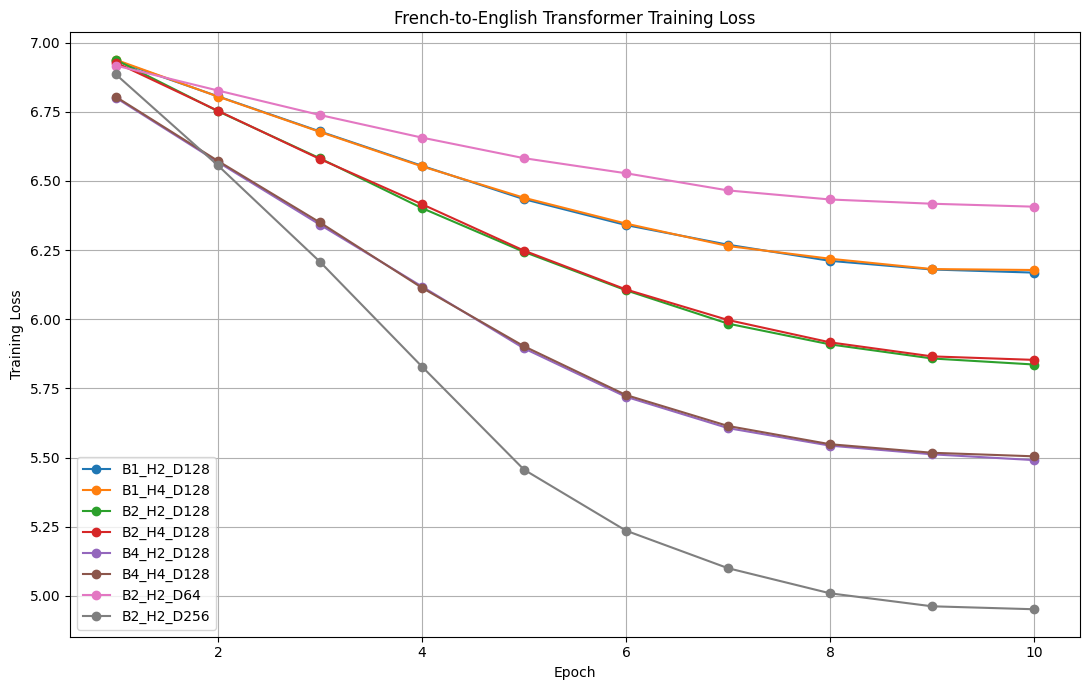

In [29]:
plt.figure(figsize=(11, 7))

for configuration_name, experiment in problem4_experiments.items():
    history = experiment["history"]

    epochs = range(
        1,
        len(history["training_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["training_loss"],
        marker="o",
        label=configuration_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("French-to-English Transformer Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "problem4_training_loss_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

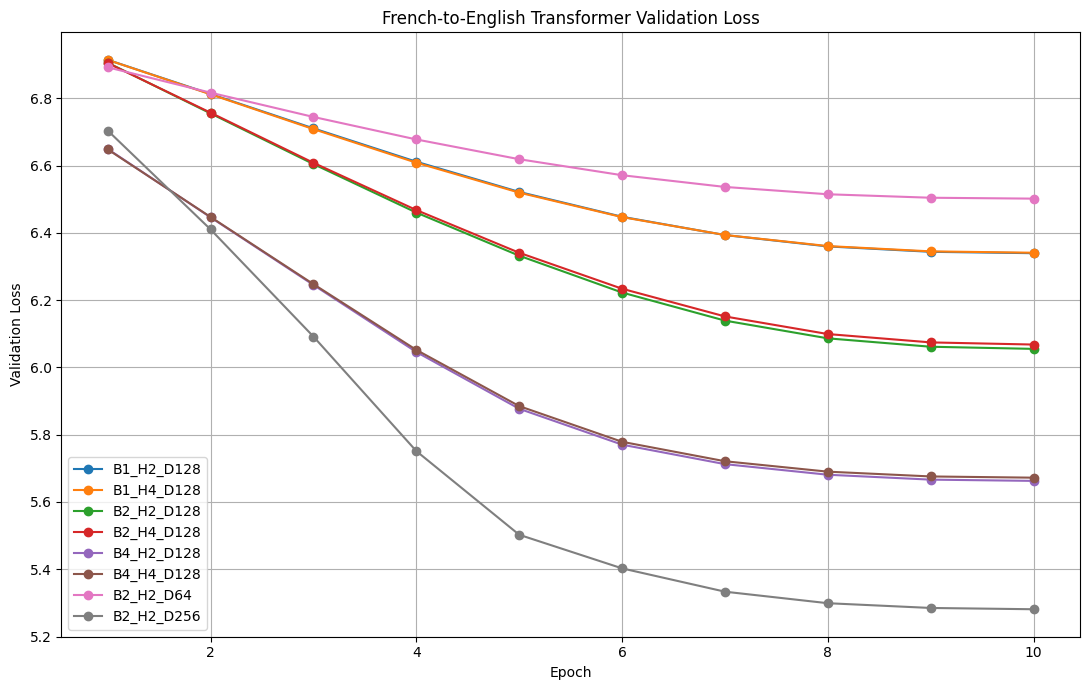

In [30]:
plt.figure(figsize=(11, 7))

for configuration_name, experiment in problem4_experiments.items():
    history = experiment["history"]

    epochs = range(
        1,
        len(history["validation_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        marker="o",
        label=configuration_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("French-to-English Transformer Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "problem4_validation_loss_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

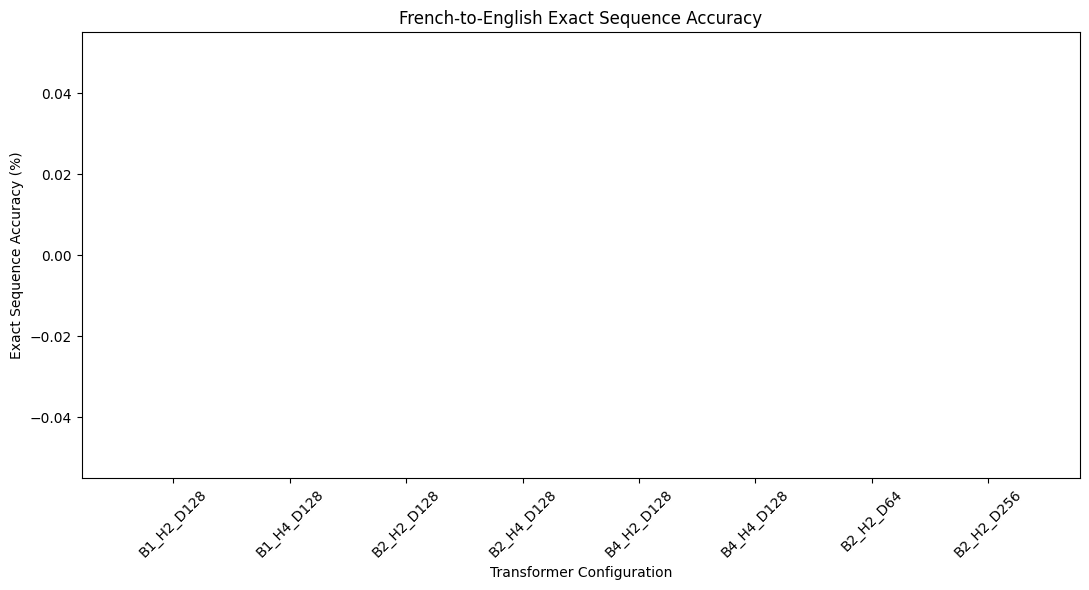

In [31]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem4_results["Configuration"],
    problem4_results["Sequence Accuracy (%)"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Exact Sequence Accuracy (%)")
plt.title("French-to-English Exact Sequence Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem4_sequence_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

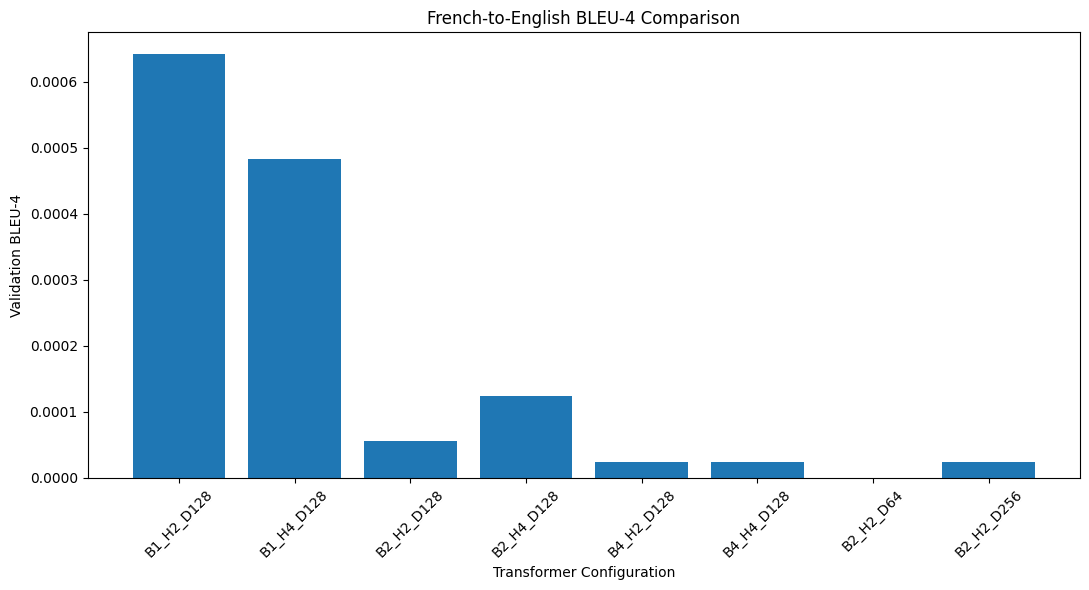

In [32]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem4_results["Configuration"],
    problem4_results["Validation BLEU-4"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Validation BLEU-4")
plt.title("French-to-English BLEU-4 Comparison")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem4_bleu4_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

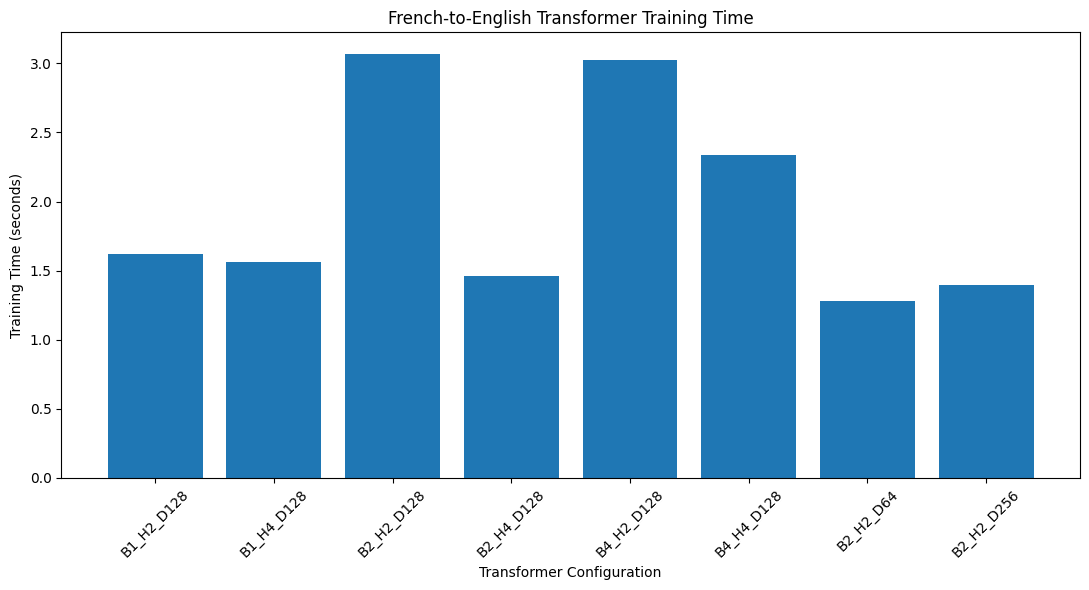

In [33]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem4_results["Configuration"],
    problem4_results["Training Time (s)"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Training Time (seconds)")
plt.title("French-to-English Transformer Training Time")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem4_training_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

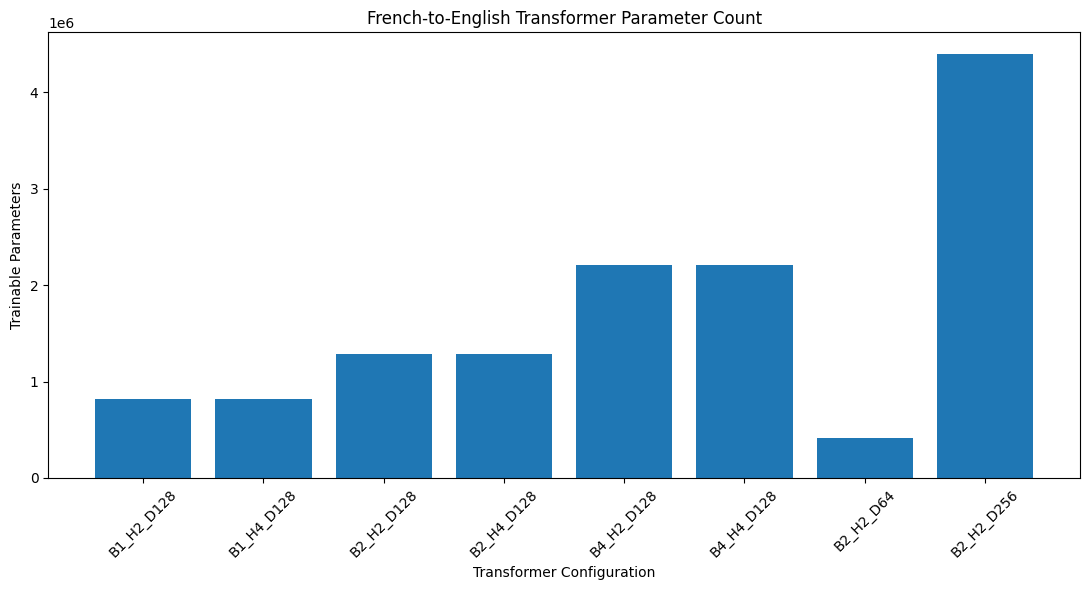

In [34]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem4_results["Configuration"],
    problem4_results["Parameters"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Trainable Parameters")
plt.title("French-to-English Transformer Parameter Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem4_parameter_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
best_configuration_name = (
    ranked_problem4_results.loc[
        0,
        "Configuration"
    ]
)

best_configuration = next(
    configuration
    for configuration in PROBLEM4_CONFIGURATIONS
    if configuration["name"]
    == best_configuration_name
)

best_checkpoint = (
    ranked_problem4_results.loc[
        0,
        "Checkpoint"
    ]
)

best_problem4_model = TranslationTransformer(
    source_vocabulary_size=FRENCH_VOCABULARY_SIZE,
    target_vocabulary_size=ENGLISH_VOCABULARY_SIZE,
    source_padding_index=FRENCH_PAD_INDEX,
    target_padding_index=ENGLISH_PAD_INDEX,
    d_model=best_configuration["d_model"],
    number_of_heads=best_configuration[
        "number_of_heads"
    ],
    number_of_layers=best_configuration[
        "number_of_layers"
    ],
    feedforward_size=best_configuration[
        "feedforward_size"
    ],
    dropout=DROPOUT,
    maximum_source_length=MAX_FRENCH_LENGTH,
    maximum_target_length=MAX_ENGLISH_LENGTH
).to(device)

best_problem4_model.load_state_dict(
    torch.load(
        best_checkpoint,
        map_location=device
    )
)

best_problem4_model.eval()

print("Best configuration:", best_configuration_name)

Best configuration: B1_H2_D128


In [36]:
@torch.no_grad()
def translate_french_to_english(
    model,
    french_sentence
):
    encoded_source = encode_sentence(
        french_sentence,
        french_token_to_index,
        MAX_FRENCH_LENGTH
    )

    source_tensor = torch.tensor(
        encoded_source,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_indices = greedy_decode_batch(
        model,
        source_tensor,
        maximum_target_length=MAX_ENGLISH_LENGTH
    )[0].cpu()

    generated_tokens = clean_token_indices(
        generated_indices,
        english_index_to_token
    )

    return detokenize(generated_tokens)


english_reference, french_input = validation_pairs[0]

generated_english = translate_french_to_english(
    best_problem4_model,
    french_input
)

print("French input:", french_input)
print("Reference English:", english_reference)
print("Generated English:", generated_english)

French input: Elle a gagné un match de tennis
Reference English: She won a tennis match
Generated English: they she path documentaries three-course loudly car beach study before


In [37]:
def create_qualitative_examples(
    model,
    number_of_examples=10
):
    smoothing = SmoothingFunction().method1

    selected_indices = np.linspace(
        0,
        len(validation_pairs) - 1,
        number_of_examples,
        dtype=int
    )

    rows = []

    for validation_index in selected_indices:
        reference_english, french_sentence = (
            validation_pairs[validation_index]
        )

        generated_english = translate_french_to_english(
            model,
            french_sentence
        )

        # Use the encoded reference for consistency
        # with the quantitative evaluation.
        encoded_reference = validation_english_tensor[
            validation_index
        ]

        reference_tokens = clean_token_indices(
            encoded_reference,
            english_index_to_token
        )

        generated_tokens = tokenize(
            generated_english
        )

        exact_match = (
            generated_tokens == reference_tokens
        )

        individual_bleu_4 = sentence_bleu(
            [reference_tokens],
            generated_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothing
        )

        rows.append({
            "French Input": french_sentence,
            "Reference English": detokenize(
                reference_tokens
            ),
            "Generated English": generated_english,
            "Exact Match": exact_match,
            "Sentence BLEU-4": individual_bleu_4
        })

    return pd.DataFrame(rows)


problem4_qualitative_results = create_qualitative_examples(
    best_problem4_model,
    number_of_examples=10
)

pd.set_option("display.max_colwidth", 300)

problem4_qualitative_results

,French Input,Reference English,Generated English,Exact Match,Sentence BLEU-4
0,Elle a gagné un match de tennis,she won a tennis match,they she path documentaries three-course loudly car beach study before,False,0.021105
1,Il conduit une berline noire,he drives a black sedan,they she path i,False,0.000000
2,La bibliothèque est un endroit calme,the library is a quiet place,they she path i,False,0.000000
3,Le chien aboie bruyamment,the dog <unk> loudly,they she path i,False,0.000000
4,Elle a remporté la première place au concours d'écriture,she won <unk> place in the <unk> <unk>,they she path documentaries three-course loudly car beach study before,False,0.021105
5,Elle visite ses grands-parents,she <unk> her <unk>,they she path documentaries three-course loudly car beach study before,False,0.021105
6,Elle peint sa chambre en blanc,she paints her room white,they she path i,False,0.062571
7,Le moteur fait un bruit étrange au démarrage,the <unk> makes a <unk> <unk> when <unk>,they she path documentaries three-course loudly car beach study before,False,0.000000
8,Le chat grimpe sur le grand arbre,the cat climbs the tall tree,they she path documentaries three-course loudly car beach study before,False,0.000000
9,Nous devons acheter une douzaine d'œufs frais,we need to buy a <unk> fresh eggs,they she path documentaries three-course loudly car beach study before,False,0.000000


In [38]:
problem4_qualitative_results.to_csv(
    "problem4_qualitative_translations.csv",
    index=False
)

print("Saved: problem4_qualitative_translations.csv")

Saved: problem4_qualitative_translations.csv


In [39]:
homework3_french_to_english = pd.DataFrame([
    {
        "Model": "Homework 3 Baseline GRU",
        "Validation Loss": 5.1740,
        "Sequence Accuracy (%)": 0.00,
        "Validation BLEU-4": 0.0502
    },
    {
        "Model": "Homework 3 Attention GRU",
        "Validation Loss": 5.5524,
        "Sequence Accuracy (%)": 0.00,
        "Validation BLEU-4": 0.1334
    }
])

homework3_french_to_english

,Model,Validation Loss,Sequence Accuracy (%),Validation BLEU-4
0,Homework 3 Baseline GRU,5.1740,0.0,0.0502
1,Homework 3 Attention GRU,5.5524,0.0,0.1334


In [40]:
best_transformer_result = (
    ranked_problem4_results.iloc[0]
)

best_transformer_comparison = pd.DataFrame([
    {
        "Model": (
            "Transformer "
            + best_transformer_result[
                "Configuration"
            ]
        ),
        "Validation Loss": best_transformer_result[
            "Validation Loss"
        ],
        "Sequence Accuracy (%)": best_transformer_result[
            "Sequence Accuracy (%)"
        ],
        "Validation BLEU-4": best_transformer_result[
            "Validation BLEU-4"
        ]
    }
])

problem4_transformer_vs_rnn = pd.concat(
    [
        homework3_french_to_english,
        best_transformer_comparison
    ],
    ignore_index=True
)

problem4_transformer_vs_rnn.round({
    "Validation Loss": 4,
    "Sequence Accuracy (%)": 2,
    "Validation BLEU-4": 4
})

,Model,Validation Loss,Sequence Accuracy (%),Validation BLEU-4
0,Homework 3 Baseline GRU,5.1740,0.0,0.0502
1,Homework 3 Attention GRU,5.5524,0.0,0.1334
2,Transformer B1_H2_D128,6.3395,0.0,0.0006


In [41]:
problem4_transformer_vs_rnn.to_csv(
    "problem4_transformer_vs_homework3.csv",
    index=False
)

print("Saved: problem4_transformer_vs_homework3.csv")

Saved: problem4_transformer_vs_homework3.csv


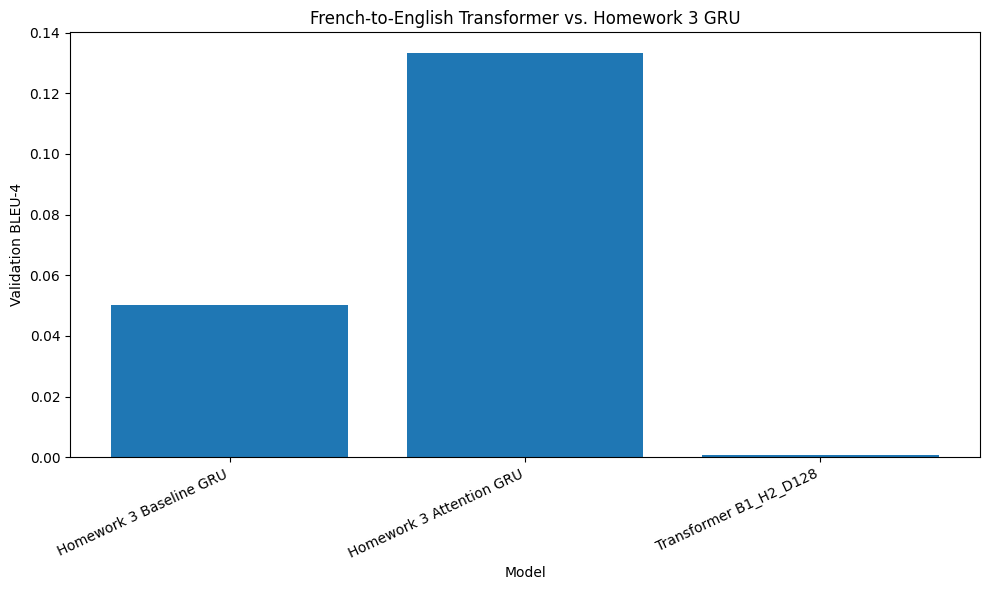

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    problem4_transformer_vs_rnn["Model"],
    problem4_transformer_vs_rnn[
        "Validation BLEU-4"
    ]
)

plt.xlabel("Model")
plt.ylabel("Validation BLEU-4")
plt.title(
    "French-to-English Transformer vs. Homework 3 GRU"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    "problem4_transformer_vs_homework3_bleu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

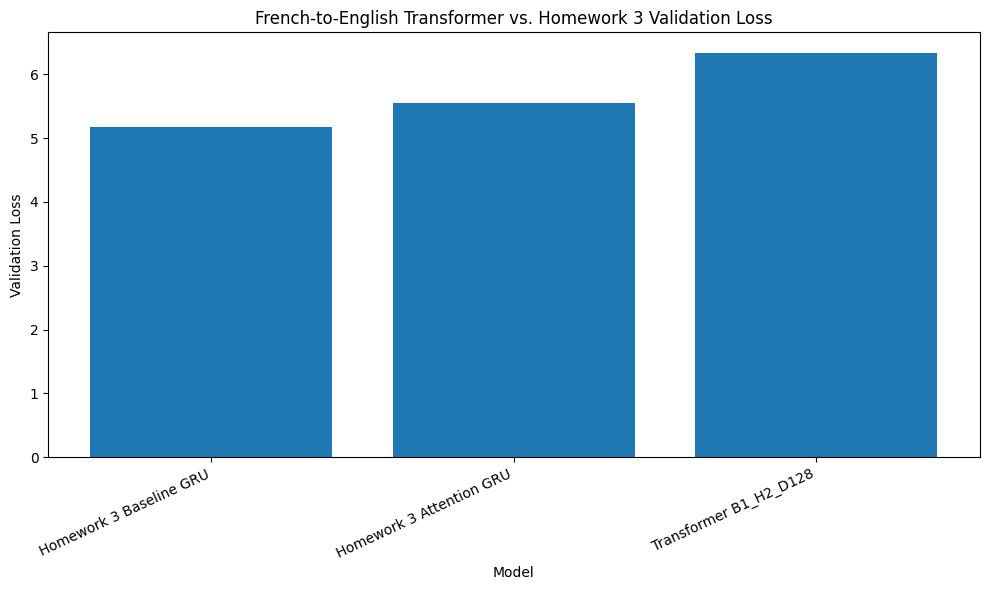

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    problem4_transformer_vs_rnn["Model"],
    problem4_transformer_vs_rnn[
        "Validation Loss"
    ]
)

plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.title(
    "French-to-English Transformer vs. Homework 3 Validation Loss"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    "problem4_transformer_vs_homework3_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
PROBLEM3_RESULTS_FILE = (
    "/content/problem3_transformer_results.csv"
)

if not os.path.exists(PROBLEM3_RESULTS_FILE):
    print(
        "Upload problem3_transformer_results.csv "
        "to compare the two translation directions."
    )

    uploaded = files.upload()

    if "problem3_transformer_results.csv" in uploaded:
        PROBLEM3_RESULTS_FILE = (
            "/content/problem3_transformer_results.csv"
        )

In [45]:
if os.path.exists(PROBLEM3_RESULTS_FILE):
    problem3_results = pd.read_csv(
        PROBLEM3_RESULTS_FILE
    )

    best_problem3_result = (
        problem3_results
        .sort_values(
            by=[
                "Validation BLEU-4",
                "Validation Loss"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]
    )

    direction_comparison = pd.DataFrame([
        {
            "Direction": "English-to-French",
            "Best Configuration": best_problem3_result[
                "Configuration"
            ],
            "Validation Loss": best_problem3_result[
                "Validation Loss"
            ],
            "Sequence Accuracy (%)": best_problem3_result[
                "Sequence Accuracy (%)"
            ],
            "Validation BLEU-4": best_problem3_result[
                "Validation BLEU-4"
            ]
        },
        {
            "Direction": "French-to-English",
            "Best Configuration": best_transformer_result[
                "Configuration"
            ],
            "Validation Loss": best_transformer_result[
                "Validation Loss"
            ],
            "Sequence Accuracy (%)": best_transformer_result[
                "Sequence Accuracy (%)"
            ],
            "Validation BLEU-4": best_transformer_result[
                "Validation BLEU-4"
            ]
        }
    ])

    direction_comparison.to_csv(
        "problem4_direction_comparison.csv",
        index=False
    )

    display(
        direction_comparison.round({
            "Validation Loss": 4,
            "Sequence Accuracy (%)": 2,
            "Validation BLEU-4": 4
        })
    )

else:
    print(
        "Problem 3 CSV was not uploaded. "
        "Skip the direction graph until the file is available."
    )

,Direction,Best Configuration,Validation Loss,Sequence Accuracy (%),Validation BLEU-4
0,English-to-French,B2_H4_D128,4.2464,0.0,0.0280
1,French-to-English,B1_H2_D128,6.3395,0.0,0.0006


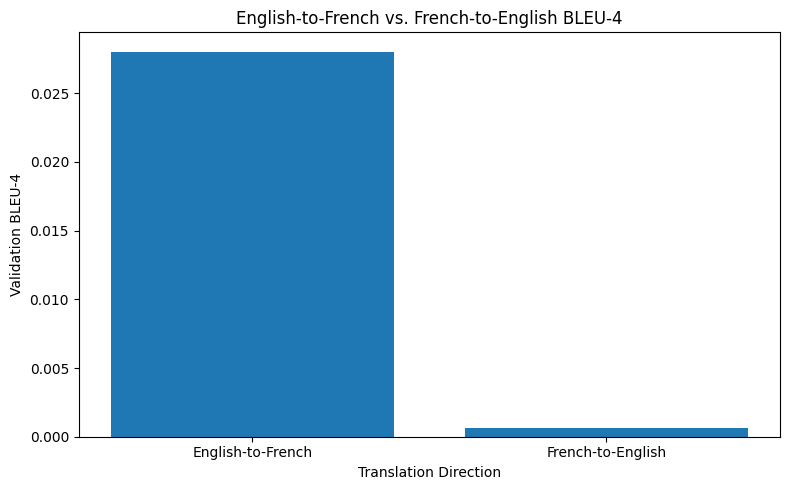

In [46]:
if "direction_comparison" in globals():
    plt.figure(figsize=(8, 5))

    plt.bar(
        direction_comparison["Direction"],
        direction_comparison[
            "Validation BLEU-4"
        ]
    )

    plt.xlabel("Translation Direction")
    plt.ylabel("Validation BLEU-4")

    plt.title(
        "English-to-French vs. French-to-English BLEU-4"
    )

    plt.tight_layout()

    plt.savefig(
        "problem4_direction_bleu_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

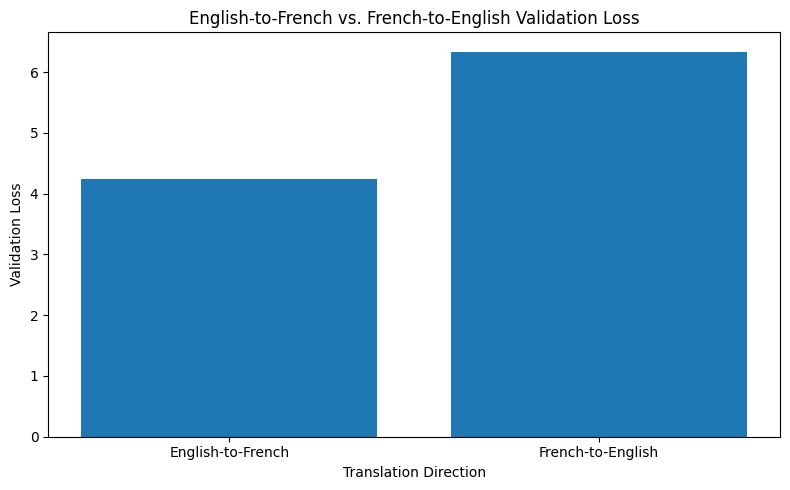

In [47]:
if "direction_comparison" in globals():
    plt.figure(figsize=(8, 5))

    plt.bar(
        direction_comparison["Direction"],
        direction_comparison[
            "Validation Loss"
        ]
    )

    plt.xlabel("Translation Direction")
    plt.ylabel("Validation Loss")

    plt.title(
        "English-to-French vs. French-to-English Validation Loss"
    )

    plt.tight_layout()

    plt.savefig(
        "problem4_direction_loss_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [48]:
problem4_information = {
    "direction": "French-to-English",
    "random_seed": SEED,
    "split_seed": SPLIT_SEED,
    "training_pairs": len(train_pairs),
    "validation_pairs": len(validation_pairs),
    "english_vocabulary_size": (
        ENGLISH_VOCABULARY_SIZE
    ),
    "french_vocabulary_size": (
        FRENCH_VOCABULARY_SIZE
    ),
    "maximum_french_length": (
        MAX_FRENCH_LENGTH
    ),
    "maximum_english_length": (
        MAX_ENGLISH_LENGTH
    ),
    "batch_size": BATCH_SIZE,
    "epochs": NUMBER_OF_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "dropout": DROPOUT
}

with open(
    "problem4_experiment_information.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        problem4_information,
        file,
        indent=4
    )

print("Saved: problem4_experiment_information.json")

Saved: problem4_experiment_information.json


In [49]:
OUTPUT_FOLDER = "problem4_results"
ZIP_NAME = "problem4_results"

if os.path.exists(OUTPUT_FOLDER):
    shutil.rmtree(OUTPUT_FOLDER)

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)

allowed_extensions = (
    ".csv",
    ".png",
    ".json",
    ".npy",
    ".txt"
)

output_files = [
    filename
    for filename in os.listdir(".")
    if filename.startswith("problem4_")
    and filename.endswith(allowed_extensions)
    and os.path.isfile(filename)
]

for filename in output_files:
    shutil.copy(
        filename,
        os.path.join(
            OUTPUT_FOLDER,
            filename
        )
    )

zip_path = f"{ZIP_NAME}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    ZIP_NAME,
    "zip",
    OUTPUT_FOLDER
)

print("Created:", zip_path)
print("\nFiles included:")

for filename in sorted(output_files):
    print(" -", filename)

Created: problem4_results.zip

Files included:
 - problem4_bleu4_comparison.png
 - problem4_direction_bleu_comparison.png
 - problem4_direction_comparison.csv
 - problem4_direction_loss_comparison.png
 - problem4_epoch_history.csv
 - problem4_experiment_information.json
 - problem4_parameter_comparison.png
 - problem4_qualitative_translations.csv
 - problem4_sequence_accuracy.png
 - problem4_train_indices.npy
 - problem4_training_loss_curves.png
 - problem4_training_time.png
 - problem4_transformer_results.csv
 - problem4_transformer_vs_homework3.csv
 - problem4_transformer_vs_homework3_bleu.png
 - problem4_transformer_vs_homework3_loss.png
 - problem4_validation_indices.npy
 - problem4_validation_loss_curves.png


In [50]:
from google.colab import files

files.download(
    "problem4_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>